In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [2]:
# creating synthetic dataset
X,Y = make_classification( n_samples=100, 
                           n_features=2, 
                           n_informative=1,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           random_state=41,
                           hypercube=False,
                           class_sep=10)

In [3]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [4]:
Y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [10]:
np.unique(Y)

array([0, 1])

In [11]:
Y = np.where(Y==0,-1,Y)

In [12]:
np.unique(Y)

array([-1,  1])

In [13]:
Y

array([ 1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1, -1,  1,  1, -1,  1,  1,
       -1,  1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1,  1,
        1,  1, -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1, -1, -1, -1,  1,
        1, -1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1, -1,  1,
       -1, -1, -1,  1,  1, -1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1,
       -1, -1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1, -1,  1,  1])

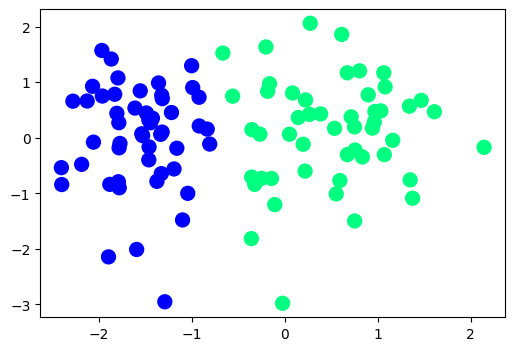

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0],X[:,1],c=Y,cmap='winter',s=100)

In [6]:
X.shape

(100, 2)

In [39]:
X[0].shape

(2,)

In [40]:
Y.shape

(100,)

In [41]:
Y[0].shape

()

In [7]:
X.shape[1]

2

In [8]:
def step(z):
    return 1 if z >= 0 else 0

In [9]:
def Perceptron(X,Y):
    X = np.insert(X,0,1,axis=1) # put value 1 at the 0th index along axis=1 (vertically)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100) # picking a random sample from the 100 samples
        Y_hat = step(np.dot(X[j],weights))  # step function converts 1 for any value >=0 else 0
        weights = weights + lr*(Y[j] - Y_hat)*X[j]
    
    return weights[0],weights[1:] # returning bias and weights

In [ ]:
def grad_Perceptron(X,Y):
    lr = 0.1
    weights = np.ones(X.shape[1])
    bias = 0
    epochoes = 1000

    for i in range(epochoes):
        error = 0
        for j in range(X.shape[0]):
            z = np.dot(X[j],weights) + bias
            
            # hinge loss max(0, -Y_i*f(X_i)) we need to minimize this loss function using grad_descent
            if Y[j]*z <= 0: # misclassification
                # update weights and bias for each of the datat points
                weights[0] = weights[0] + lr*Y[j]*X[j][0]
                weights[1] = weights[1] +lr*Y[j]*X[j][1]
                bias = bias + lr*Y[j]
        if error ==0:
            break
        
    return weights,bias
                

In [9]:
_intercept_,_coef_ = Perceptron(X,Y)

In [31]:
weights,bias = grad_Perceptron(X,Y)

In [10]:
_intercept_

np.float64(0.9)

In [24]:
bias

np.float64(0.6)

In [11]:
_coef_

array([1.31800899, 0.17014362])

In [25]:
weights

array([ 0.94479019, -0.03102592])

In [12]:
m = -_coef_[0]/_coef_[1]
b = -_intercept_/_coef_[1]

In [33]:
m_loss = -weights[0]/weights[1]
b_loss = -bias/weights[1]

In [35]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

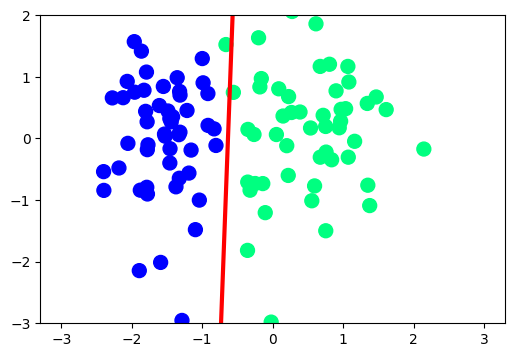

In [36]:
plt.figure(figsize=(6,4))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=Y,cmap='winter',s=100)
plt.ylim(-3,2) # setting the y limits because my scatter plots were geeting squished in bigger assumed limits

In [37]:
x_input_loss = np.linspace(-3,3,100)
y_input_loss = m_loss*x_input + b_loss

(-3.0, 2.0)

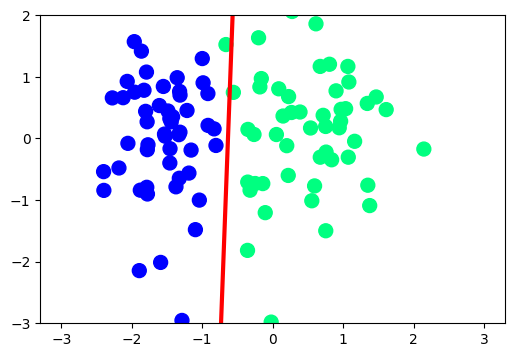

In [38]:
plt.figure(figsize=(6,4))
plt.plot(x_input_loss,y_input_loss,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=Y,cmap='winter',s=100)
plt.ylim(-3,2) # setting the y limits because my scatter plots were geeting squished in bigger assumed limits